# Credit Risk Default Prediction

This notebook builds an interpretable credit-risk baseline using only `data/raw/application_train.csv` from the Home Credit dataset. It covers data checks, EDA, feature engineering, Logistic Regression, model evaluation, and risk segmentation.

Dataset context: each row represents a loan application. `TARGET = 1` identifies an **observed payment-difficulty outcome under the dataset definition**, while `TARGET = 0` identifies no observed payment difficulty. The project title uses "default prediction" as shorthand, but the target is not a general contractual or lender-specific definition of default.

## 1. Import Libraries

We use a compact Python data science stack: pandas/numpy for data preparation, seaborn/matplotlib for EDA, and scikit-learn for preprocessing, modeling, and evaluation.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "application_train.csv"
DESCRIPTION_PATH = PROJECT_ROOT / "data" / "raw" / "HomeCredit_columns_description.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CLASSIFICATION_THRESHOLD = 0.15
LOW_RISK_CUTOFF = 0.05
HIGH_RISK_CUTOFF = 0.15
OUTCOME_ORDER = ["No Observed Payment Difficulty", "Observed Payment Difficulty"]


def project_relative_path(path: Path) -> str:
    """Return a path relative to the project root for portable notebook output."""
    return str(path.relative_to(PROJECT_ROOT))


def save_figure(fig, filename: str):
    """Save, display, and close one Matplotlib figure."""
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return project_relative_path(path)

## 2. Load Data

Only `application_train.csv` is used for analysis and modeling. `HomeCredit_columns_description.csv` is read only for field definitions. The description file contains rows for several Home Credit tables, so the code first identifies the application train/test table label and only then filters the selected fields.

In [2]:
selected_columns = [
    "SK_ID_CURR",
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
]

df_raw = pd.read_csv(DATA_PATH, usecols=selected_columns)

try:
    columns_description = pd.read_csv(DESCRIPTION_PATH, encoding="ISO-8859-1")
    description_table_values = columns_description["Table"].dropna().astype(str).unique().tolist()
    application_table_candidates = [
        table_name
        for table_name in description_table_values
        if "application" in table_name.lower()
        and "train" in table_name.lower()
    ]
    if len(application_table_candidates) != 1:
        raise ValueError(
            "Could not identify one application train/test description table. "
            f"Candidates found: {application_table_candidates}"
        )
    application_description_table = application_table_candidates[0]
    field_descriptions = (
        columns_description.loc[
            columns_description["Table"].eq(application_description_table)
            & columns_description["Row"].isin(selected_columns),
            ["Table", "Row", "Description"],
        ]
        .drop_duplicates(subset=["Row"])
        .sort_values("Row")
        .reset_index(drop=True)
    )
    if field_descriptions["Row"].duplicated().any():
        raise ValueError("Application-table field descriptions are not unique by field name.")
except FileNotFoundError:
    columns_description = pd.DataFrame()
    application_description_table = "Description file not available"
    field_descriptions = pd.DataFrame(columns=["Table", "Row", "Description"])

print(f"Raw data shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} selected columns")
print(f"Data source: {project_relative_path(DATA_PATH)}")
print(f"Description table used: {application_description_table}")
print("\nSelected application-table field descriptions:")
display(field_descriptions)

Raw data shape: 307,511 rows x 16 selected columns
Data source: data/raw/application_train.csv
Description table used: application_{train|test}.csv

Selected application-table field descriptions:


,Table,Row,Description
0,application_{train|test}.csv,AMT_ANNUITY,Loan annuity
1,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan
2,application_{train|test}.csv,AMT_GOODS_PRICE,For consumer loans it is the price of the good...
3,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client
4,application_{train|test}.csv,CODE_GENDER,Gender of the client
5,application_{train|test}.csv,DAYS_BIRTH,Client's age in days at the time of application
6,application_{train|test}.csv,DAYS_EMPLOYED,How many days before the application the perso...
7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car
8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat
9,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving


## 3. Data Overview

Before modeling, this section checks the intended row grain and target validity. `SK_ID_CURR` is the application identifier: it is used only to test uniqueness and is explicitly excluded from model features.

In [3]:
display(df_raw.head())

row_count = len(df_raw)
missing_id_count = int(df_raw["SK_ID_CURR"].isna().sum())
unique_application_ids = df_raw["SK_ID_CURR"].nunique(dropna=True)
duplicate_id_count = int(df_raw["SK_ID_CURR"].duplicated().sum())
exact_duplicate_row_count = int(df_raw.duplicated().sum())
target_missing_count = int(df_raw["TARGET"].isna().sum())
observed_target_values = sorted(df_raw["TARGET"].dropna().unique().tolist())
unexpected_target_values = sorted(set(observed_target_values) - {0, 1})

data_quality_summary = pd.DataFrame([
    {"check": "Total rows", "value": row_count, "expected": "307,511 in source file"},
    {"check": "Missing SK_ID_CURR values", "value": missing_id_count, "expected": "0"},
    {"check": "Unique SK_ID_CURR values", "value": unique_application_ids, "expected": "Equal to total rows"},
    {"check": "Duplicate SK_ID_CURR rows", "value": duplicate_id_count, "expected": "0"},
    {"check": "Fully duplicate rows", "value": exact_duplicate_row_count, "expected": "0"},
    {"check": "Missing TARGET values", "value": target_missing_count, "expected": "0"},
    {"check": "Unexpected TARGET values", "value": len(unexpected_target_values), "expected": "0; TARGET must be 0/1"},
])

display(data_quality_summary)
print("Observed TARGET values:", observed_target_values)

assert missing_id_count == 0, "SK_ID_CURR contains missing values."
assert unique_application_ids == row_count, (
    "SK_ID_CURR must uniquely identify every application."
)
assert duplicate_id_count == 0, "SK_ID_CURR must be unique at the application grain."
assert exact_duplicate_row_count == 0, "Fully duplicated application rows were found."
assert target_missing_count == 0, "TARGET contains missing values."
assert not unexpected_target_values, f"Unexpected TARGET values: {unexpected_target_values}"

overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null_count": df_raw.notna().sum(),
    "missing_count": df_raw.isna().sum(),
    "missing_rate": df_raw.isna().mean(),
    "unique_values": df_raw.nunique(dropna=True),
}).sort_values("missing_rate", ascending=False)

display(overview)
display(df_raw.describe(include="all").T)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE
0,100002,1,Cash loans,M,N,Y,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Secondary / secondary special,Single / not married,House / apartment,-9461,-637,Laborers
1,100003,0,Cash loans,F,N,N,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Higher education,Married,House / apartment,-16765,-1188,Core staff
2,100004,0,Revolving loans,M,Y,Y,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Secondary / secondary special,Single / not married,House / apartment,-19046,-225,Laborers
3,100006,0,Cash loans,F,N,Y,"135,000.0000","312,682.5000","29,686.5000","297,000.0000",Secondary / secondary special,Civil marriage,House / apartment,-19005,-3039,Laborers
4,100007,0,Cash loans,M,N,Y,"121,500.0000","513,000.0000","21,865.5000","513,000.0000",Secondary / secondary special,Single / not married,House / apartment,-19932,-3038,Core staff


,check,value,expected
0,Total rows,307511,"307,511 in source file"
1,Missing SK_ID_CURR values,0,0
2,Unique SK_ID_CURR values,307511,Equal to total rows
3,Duplicate SK_ID_CURR rows,0,0
4,Fully duplicate rows,0,0
5,Missing TARGET values,0,0
6,Unexpected TARGET values,0,0; TARGET must be 0/1


Observed TARGET values: [0, 1]


,dtype,non_null_count,missing_count,missing_rate,unique_values
OCCUPATION_TYPE,object,211120,96391,0.3135,18
AMT_GOODS_PRICE,float64,307233,278,0.0009,1002
AMT_ANNUITY,float64,307499,12,0.0000,13672
SK_ID_CURR,int64,307511,0,0.0000,307511
TARGET,int64,307511,0,0.0000,2
NAME_CONTRACT_TYPE,object,307511,0,0.0000,2
CODE_GENDER,object,307511,0,0.0000,3
FLAG_OWN_CAR,object,307511,0,0.0000,2
FLAG_OWN_REALTY,object,307511,0,0.0000,2
AMT_INCOME_TOTAL,float64,307511,0,0.0000,2548


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,"307,511.0000",NaN,NaN,NaN,"278,180.5186","102,790.1753","100,002.0000","189,145.5000","278,202.0000","367,142.5000","456,255.0000"
TARGET,"307,511.0000",NaN,NaN,NaN,0.0807,0.2724,0.0000,0.0000,0.0000,0.0000,1.0000
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,307511,2,Y,213312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMT_INCOME_TOTAL,"307,511.0000",NaN,NaN,NaN,"168,797.9193","237,123.1463","25,650.0000","112,500.0000","147,150.0000","202,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000",NaN,NaN,NaN,"599,025.9997","402,490.7770","45,000.0000","270,000.0000","513,531.0000","808,650.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000",NaN,NaN,NaN,"27,108.5739","14,493.7373","1,615.5000","16,524.0000","24,903.0000","34,596.0000","258,025.5000"
AMT_GOODS_PRICE,"307,233.0000",NaN,NaN,NaN,"538,396.2074","369,446.4605","40,500.0000","238,500.0000","450,000.0000","679,500.0000","4,050,000.0000"


## 4. Target Variable Analysis

`TARGET = 1` represents an observed payment-difficulty outcome under the dataset definition; `TARGET = 0` represents no observed payment difficulty. The label is used as the modeling outcome, not as a general definition of default.

The full-sample event rate is about 8.1%, so the positive class is relatively uncommon. A model can appear accurate by predicting mostly non-events while failing to capture applications with observed payment difficulty. Risk capture and ranking matter more than surface-level accuracy.

Full-sample observed payment-difficulty rate (TARGET = 1): 8.07%


,metric,value,description
0,full_sample_payment_difficulty_rate,0.0807,Full-sample share of applications with TARGET = 1
1,full_sample_payment_difficulty_count,"24,825.0000",Full-sample number of applications with TARGET...


,TARGET,label,application_count,percentage
0,0,No Observed Payment Difficulty,282686,0.9193
1,1,Observed Payment Difficulty,24825,0.0807


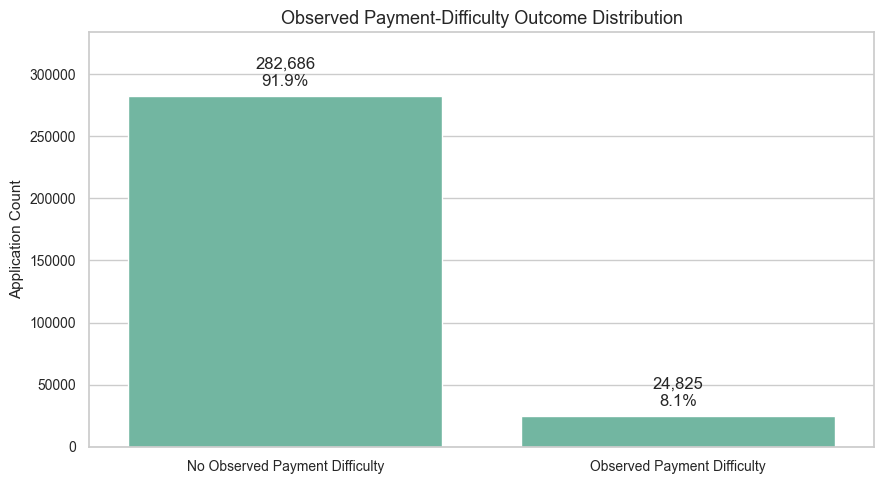

'outputs/figures/target_distribution.png'

In [4]:
full_sample_event_rate = df_raw["TARGET"].mean()
full_sample_event_count = int(df_raw["TARGET"].sum())

baseline_summary = pd.DataFrame([
    {
        "metric": "full_sample_payment_difficulty_rate",
        "value": full_sample_event_rate,
        "description": "Full-sample share of applications with TARGET = 1",
    },
    {
        "metric": "full_sample_payment_difficulty_count",
        "value": full_sample_event_count,
        "description": "Full-sample number of applications with TARGET = 1",
    },
])

target_summary = (
    df_raw["TARGET"]
    .value_counts(dropna=False)
    .rename_axis("TARGET")
    .reset_index(name="application_count")
)
target_summary["percentage"] = target_summary["application_count"] / target_summary["application_count"].sum()
target_summary["label"] = target_summary["TARGET"].map({
    0: "No Observed Payment Difficulty",
    1: "Observed Payment Difficulty",
})

print(f"Full-sample observed payment-difficulty rate (TARGET = 1): {full_sample_event_rate:.2%}")
display(baseline_summary)
display(target_summary[["TARGET", "label", "application_count", "percentage"]])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=target_summary, x="label", y="application_count", ax=ax)
ax.set_title("Observed Payment-Difficulty Outcome Distribution")
ax.set_xlabel("")
ax.set_ylabel("Application Count")
ax.set_ylim(0, target_summary["application_count"].max() * 1.18)
for patch, row in zip(ax.patches, target_summary.itertuples(index=False)):
    ax.annotate(
        f"{row.application_count:,.0f}\n{row.percentage:.1%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
    )
ax.tick_params(axis="x", rotation=0)
save_figure(fig, "target_distribution.png")

## 5. Missing Value Check

Missingness is reviewed before modeling. Numeric features are later median-imputed within the training pipeline. Categorical missing values are represented as an explicit `Unknown` category rather than being assigned to the most common observed category. This is especially important for `OCCUPATION_TYPE`, where missingness is substantial and does not imply the modal occupation.

In [5]:
missing_summary = (
    df_raw.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_rate"})
)
missing_summary["missing_count"] = missing_summary["feature"].map(df_raw.isna().sum())

display(missing_summary)

,feature,missing_rate,missing_count
0,OCCUPATION_TYPE,0.3135,96391
1,AMT_GOODS_PRICE,0.0009,278
2,AMT_ANNUITY,0.0000,12
3,SK_ID_CURR,0.0000,0
4,TARGET,0.0000,0
5,NAME_CONTRACT_TYPE,0.0000,0
6,CODE_GENDER,0.0000,0
7,FLAG_OWN_CAR,0.0000,0
8,FLAG_OWN_REALTY,0.0000,0
9,AMT_INCOME_TOTAL,0.0000,0


## 6. Basic Data Cleaning

Before the train/holdout split, the notebook applies only deterministic rules that do not learn from the overall distribution:

- convert `DAYS_BIRTH` into positive age in years;
- convert valid `DAYS_EMPLOYED` values into employment years and treat positive placeholder values as missing;
- replace negative amount values with missing values;
- protect ratio calculations from zero income; and
- convert infinite values to missing.

Distribution-based clipping is deliberately postponed until after the split. Its bounds are estimated from the training set only and then applied unchanged to both training and holdout data. This prevents the holdout distribution from influencing a preprocessing rule used by the model.

In [6]:
df = df_raw.copy()

# Normalize the rare invalid marker for descriptive checks; gender is excluded from the model.
df["CODE_GENDER"] = df["CODE_GENDER"].replace({"XNA": "Unknown"})

# Convert negative day offsets into positive year-based business variables.
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).round(1)
df["YEARS_EMPLOYED"] = np.where(
    df["DAYS_EMPLOYED"] > 0,
    np.nan,
    (-df["DAYS_EMPLOYED"] / 365.25).round(1),
)

amount_columns = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
for column in amount_columns:
    df.loc[df[column] < 0, column] = np.nan

income_denominator = df["AMT_INCOME_TOTAL"].replace(0, np.nan)
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / income_denominator
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / income_denominator

df = df.replace([np.inf, -np.inf], np.nan)

cleaning_check = df[[
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
]].describe().T

display(cleaning_check)

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,"307,511.0000",43.9070,11.9480,20.5000,34.0000,43.1000,53.9000,69.1000
YEARS_EMPLOYED,"252,137.0000",6.5274,6.4022,0.0000,2.1000,4.5000,8.7000,49.0000
CREDIT_INCOME_RATIO,"307,511.0000",3.9576,2.6897,0.0048,2.0187,3.2651,5.1599,84.7368
ANNUITY_INCOME_RATIO,"307,499.0000",0.1809,0.0946,0.0002,0.1148,0.1628,0.2291,1.8760


## 7. Feature Selection

This version uses a limited, interpretable set of application, loan, and demographic features. `SK_ID_CURR` is excluded because it is an identifier, not a risk characteristic. The original day-offset fields are used only to derive `AGE_YEARS` and `YEARS_EMPLOYED` and do not enter the model alongside those derived fields.

`CODE_GENDER` was inspected during data checks but excluded from the model. I kept the model focused on a limited set of applicant and loan characteristics. Age and family status remain as inputs, and their observed associations should not be read as causal effects.

In [7]:
numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
]

target = "TARGET"
model_features = numeric_features + categorical_features
excluded_from_model = ["SK_ID_CURR", "CODE_GENDER", "DAYS_BIRTH", "DAYS_EMPLOYED"]
model_df = df[model_features + [target]].copy()

assert not set(excluded_from_model).intersection(model_features)

print(f"Modeling table shape: {model_df.shape[0]:,} rows x {model_df.shape[1]:,} columns")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Explicitly excluded from model:", excluded_from_model)

Modeling table shape: 307,511 rows x 16 columns
Numeric features: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']
Categorical features: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
Explicitly excluded from model: ['SK_ID_CURR', 'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED']


## 8. Exploratory Data Analysis

EDA focuses on descriptive relationships that are easy to explain in a risk-analyst setting: observed payment difficulty by income, credit amount, age, leverage ratios, education, family status, and asset ownership. Plot-only clipping is used to make long-tailed distributions readable; it does not feed the model or holdout evaluation.

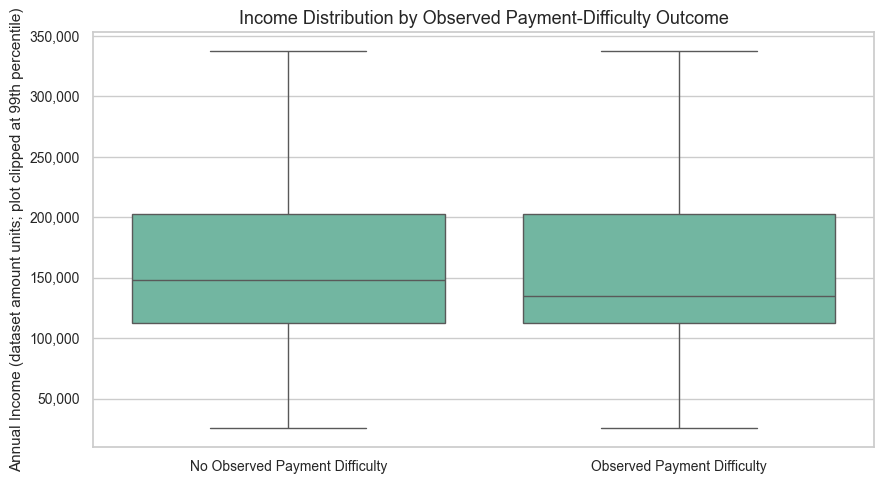

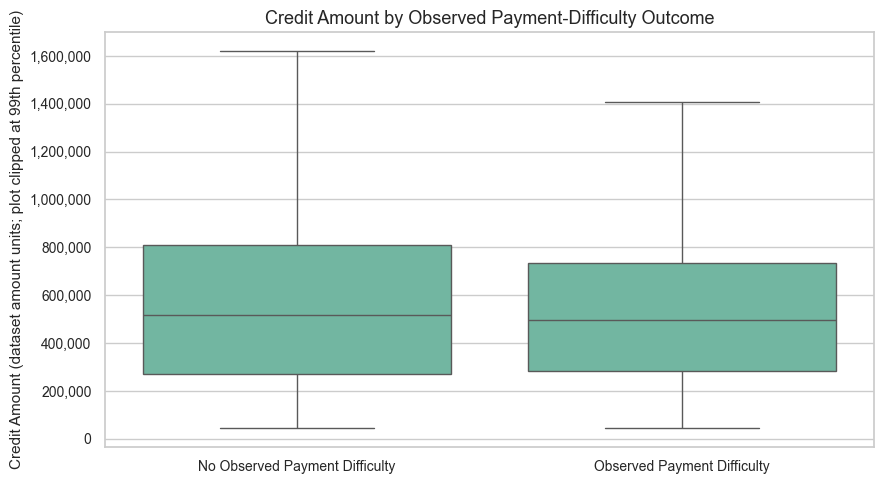

'outputs/figures/credit_by_target_boxplot.png'

In [8]:
eda_df = df.copy()
eda_df["TARGET_LABEL"] = eda_df["TARGET"].map({
    0: "No Observed Payment Difficulty",
    1: "Observed Payment Difficulty",
})
eda_df[categorical_features] = eda_df[categorical_features].fillna("Unknown")

# Income distribution by observed outcome; clipping is for display only.
plot_df = eda_df.copy()
plot_df["AMT_INCOME_TOTAL_PLOT"] = plot_df["AMT_INCOME_TOTAL"].clip(
    upper=plot_df["AMT_INCOME_TOTAL"].quantile(0.99)
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="TARGET_LABEL", y="AMT_INCOME_TOTAL_PLOT", order=OUTCOME_ORDER, showfliers=False, ax=ax)
ax.set_title("Income Distribution by Observed Payment-Difficulty Outcome")
ax.set_xlabel("")
ax.set_ylabel("Annual Income (dataset amount units; plot clipped at 99th percentile)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
save_figure(fig, "income_by_target_boxplot.png")

# Credit amount distribution by observed outcome; clipping is for display only.
plot_df["AMT_CREDIT_PLOT"] = plot_df["AMT_CREDIT"].clip(
    upper=plot_df["AMT_CREDIT"].quantile(0.99)
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="TARGET_LABEL", y="AMT_CREDIT_PLOT", order=OUTCOME_ORDER, showfliers=False, ax=ax)
ax.set_title("Credit Amount by Observed Payment-Difficulty Outcome")
ax.set_xlabel("")
ax.set_ylabel("Credit Amount (dataset amount units; plot clipped at 99th percentile)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
save_figure(fig, "credit_by_target_boxplot.png")

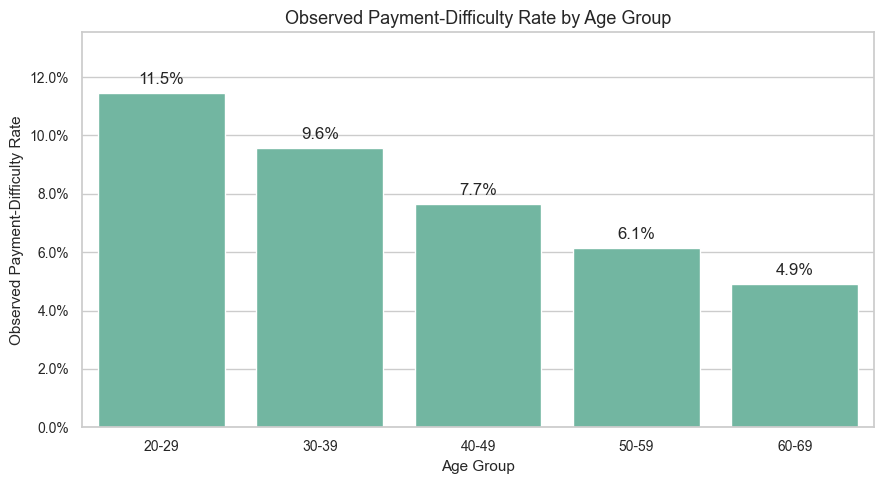

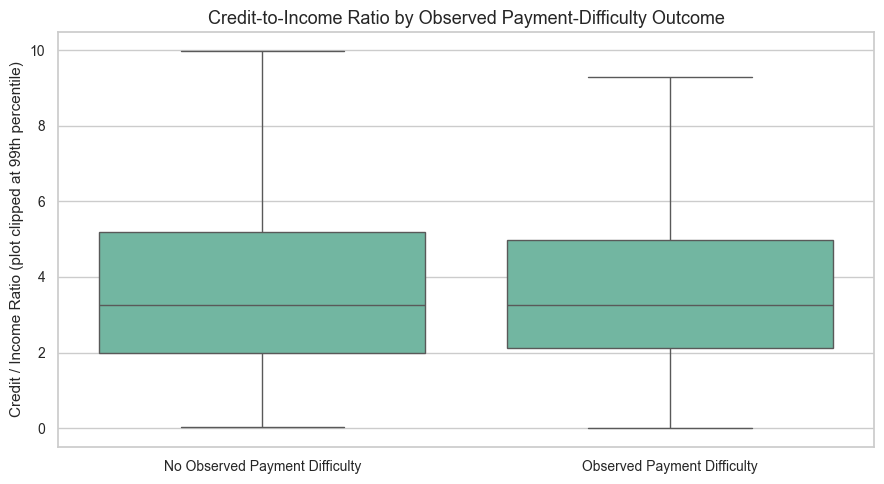

'outputs/figures/credit_income_ratio_by_target_boxplot.png'

In [9]:
# Age and observed payment-difficulty relationship
age_bins = [20, 30, 40, 50, 60, 70]
age_labels = ["20-29", "30-39", "40-49", "50-59", "60-69"]
eda_df["AGE_GROUP"] = pd.cut(eda_df["AGE_YEARS"], bins=age_bins, labels=age_labels, right=False)
age_payment_difficulty_rate = (
    eda_df.groupby("AGE_GROUP", observed=True)["TARGET"]
    .mean()
    .reset_index(name="payment_difficulty_rate")
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=age_payment_difficulty_rate, x="AGE_GROUP", y="payment_difficulty_rate", ax=ax)
ax.set_title("Observed Payment-Difficulty Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Observed Payment-Difficulty Rate")
ax.set_ylim(0, age_payment_difficulty_rate["payment_difficulty_rate"].max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
for patch, rate in zip(ax.patches, age_payment_difficulty_rate["payment_difficulty_rate"]):
    ax.annotate(
        f"{rate:.1%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )
save_figure(fig, "payment_difficulty_rate_by_age_group.png")

# Credit-to-income ratio and observed outcome; clipping is for display only.
plot_df["CREDIT_INCOME_RATIO_PLOT"] = plot_df["CREDIT_INCOME_RATIO"].clip(
    upper=plot_df["CREDIT_INCOME_RATIO"].quantile(0.99)
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="TARGET_LABEL", y="CREDIT_INCOME_RATIO_PLOT", order=OUTCOME_ORDER, showfliers=False, ax=ax)
ax.set_title("Credit-to-Income Ratio by Observed Payment-Difficulty Outcome")
ax.set_xlabel("")
ax.set_ylabel("Credit / Income Ratio (plot clipped at 99th percentile)")
save_figure(fig, "credit_income_ratio_by_target_boxplot.png")

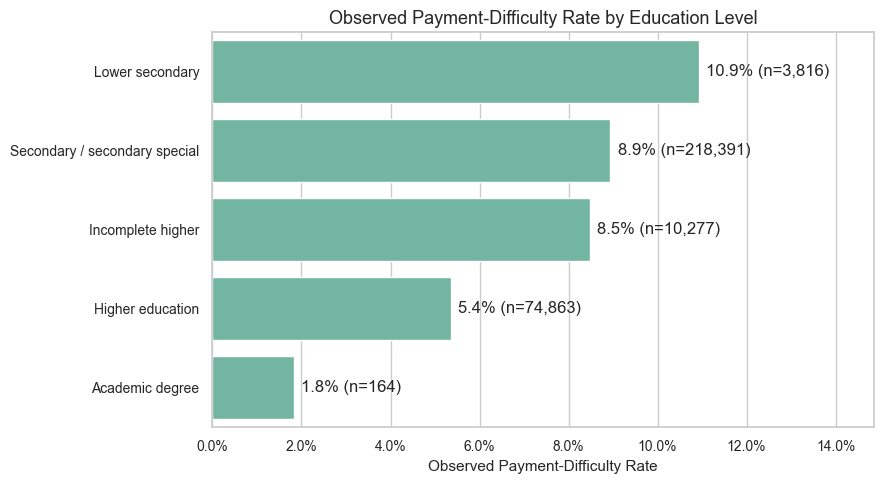

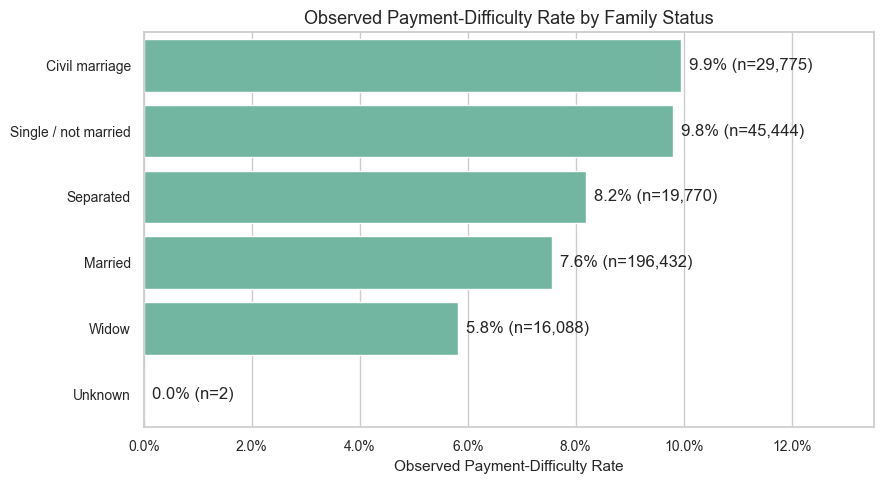

,NAME_EDUCATION_TYPE,application_count,payment_difficulty_rate
3,Lower secondary,3816,0.1093
4,Secondary / secondary special,218391,0.0894
2,Incomplete higher,10277,0.0848
1,Higher education,74863,0.0536
0,Academic degree,164,0.0183


,NAME_FAMILY_STATUS,application_count,payment_difficulty_rate
0,Civil marriage,29775,0.0994
3,Single / not married,45444,0.0981
2,Separated,19770,0.0819
1,Married,196432,0.0756
5,Widow,16088,0.0582
4,Unknown,2,0.0000


In [10]:
def plot_payment_difficulty_rate_by_category(data, category, filename, title, max_categories=None):
    category_rate = (
        data.groupby(category, observed=True)
        .agg(application_count=("TARGET", "size"), payment_difficulty_rate=("TARGET", "mean"))
        .reset_index()
        .sort_values("payment_difficulty_rate", ascending=False)
    )
    if max_categories is not None:
        category_rate = category_rate.head(max_categories)

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=category_rate, x="payment_difficulty_rate", y=category, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Observed Payment-Difficulty Rate")
    ax.set_ylabel("")
    max_rate = category_rate["payment_difficulty_rate"].max()
    label_padding = max_rate * 0.015
    ax.set_xlim(0, max_rate * 1.36)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    for patch, row in zip(ax.patches, category_rate.itertuples(index=False)):
        ax.annotate(
            f"{row.payment_difficulty_rate:.1%} (n={row.application_count:,})",
            (patch.get_width() + label_padding, patch.get_y() + patch.get_height() / 2),
            ha="left",
            va="center",
        )
    save_figure(fig, filename)
    return category_rate


education_payment_difficulty_rate = plot_payment_difficulty_rate_by_category(
    eda_df,
    "NAME_EDUCATION_TYPE",
    "payment_difficulty_rate_by_education.png",
    "Observed Payment-Difficulty Rate by Education Level",
)

family_payment_difficulty_rate = plot_payment_difficulty_rate_by_category(
    eda_df,
    "NAME_FAMILY_STATUS",
    "payment_difficulty_rate_by_family_status.png",
    "Observed Payment-Difficulty Rate by Family Status",
)

display(education_payment_difficulty_rate)
display(family_payment_difficulty_rate)

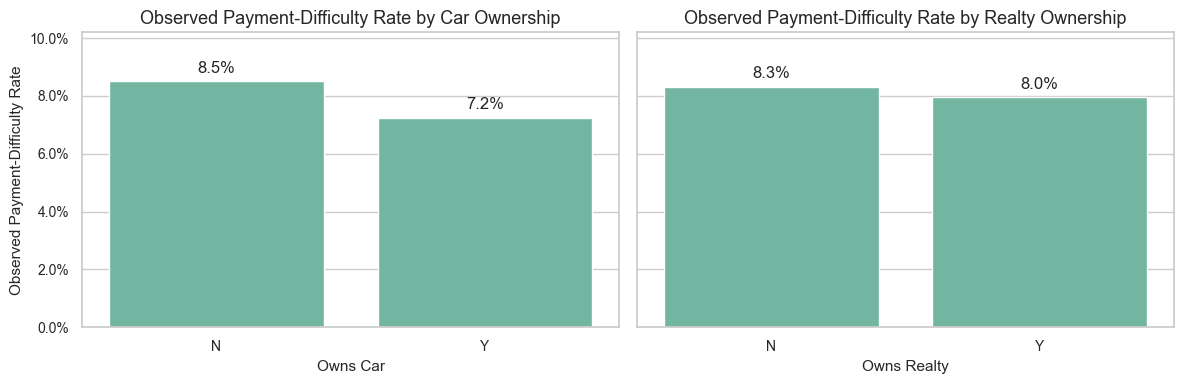

,FLAG_OWN_CAR,application_count,payment_difficulty_rate
0,N,202924,0.0850
1,Y,104587,0.0724


,FLAG_OWN_REALTY,application_count,payment_difficulty_rate
0,N,94199,0.0832
1,Y,213312,0.0796


In [11]:
car_payment_difficulty_rate = (
    eda_df.groupby("FLAG_OWN_CAR", observed=True)
    .agg(application_count=("TARGET", "size"), payment_difficulty_rate=("TARGET", "mean"))
    .reset_index()
)
realty_payment_difficulty_rate = (
    eda_df.groupby("FLAG_OWN_REALTY", observed=True)
    .agg(application_count=("TARGET", "size"), payment_difficulty_rate=("TARGET", "mean"))
    .reset_index()
)

shared_rate_max = max(
    car_payment_difficulty_rate["payment_difficulty_rate"].max(),
    realty_payment_difficulty_rate["payment_difficulty_rate"].max(),
) * 1.20

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.barplot(data=car_payment_difficulty_rate, x="FLAG_OWN_CAR", y="payment_difficulty_rate", ax=axes[0])
axes[0].set_title("Observed Payment-Difficulty Rate by Car Ownership")
axes[0].set_xlabel("Owns Car")
axes[0].set_ylabel("Observed Payment-Difficulty Rate")

sns.barplot(data=realty_payment_difficulty_rate, x="FLAG_OWN_REALTY", y="payment_difficulty_rate", ax=axes[1])
axes[1].set_title("Observed Payment-Difficulty Rate by Realty Ownership")
axes[1].set_xlabel("Owns Realty")
axes[1].set_ylabel("")

for ax, rate_table in zip(axes, [car_payment_difficulty_rate, realty_payment_difficulty_rate]):
    ax.set_ylim(0, shared_rate_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    for patch, rate in zip(ax.patches, rate_table["payment_difficulty_rate"]):
        ax.annotate(
            f"{rate:.1%}",
            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
        )

save_figure(fig, "payment_difficulty_rate_by_car_and_realty.png")

display(car_payment_difficulty_rate)
display(realty_payment_difficulty_rate)

## 9. Feature Engineering

The engineered model features are designed to be transparent in a credit-risk discussion:

- `AGE_YEARS`: approximate applicant age from the application day offset;
- `YEARS_EMPLOYED`: approximate employment length after treating positive placeholders as missing;
- `CREDIT_INCOME_RATIO`: requested credit relative to income, as a simple leverage or affordability proxy; and
- `ANNUITY_INCOME_RATIO`: scheduled annuity relative to income, as a payment-burden proxy.

These features do not replace bureau, cash-flow, or repayment-history data. They provide an interpretable first baseline. Their observed relationships are descriptive and conditional on the included variables, not causal.

In [12]:
engineered_features = [
    "AGE_YEARS",
    "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
]

feature_engineering_summary = model_df[engineered_features].describe().T
feature_engineering_summary["missing_rate"] = model_df[engineered_features].isna().mean()

display(feature_engineering_summary)

,count,mean,std,min,25%,50%,75%,max,missing_rate
AGE_YEARS,"307,511.0000",43.9070,11.9480,20.5000,34.0000,43.1000,53.9000,69.1000,0.0000
YEARS_EMPLOYED,"252,137.0000",6.5274,6.4022,0.0000,2.1000,4.5000,8.7000,49.0000,0.1801
CREDIT_INCOME_RATIO,"307,511.0000",3.9576,2.6897,0.0048,2.0187,3.2651,5.1599,84.7368,0.0000
ANNUITY_INCOME_RATIO,"307,499.0000",0.1809,0.0946,0.0002,0.1148,0.1628,0.2291,1.8760,0.0000


### 9.1 Numeric Feature Correlation Check

Several amount and ratio variables encode related financial information. A concise correlation check helps identify potential multicollinearity, especially between `AMT_CREDIT` and `AMT_GOODS_PRICE`. Correlation alone is not used to delete a feature in this baseline, but strongly related predictors can make individual Logistic Regression coefficients less stable. Coefficients are therefore treated as conditional model associations rather than isolated business effects.

In [13]:
numeric_correlation = model_df[numeric_features].corr()
upper_triangle = numeric_correlation.where(
    np.triu(np.ones(numeric_correlation.shape), k=1).astype(bool)
)
correlation_pairs = (
    upper_triangle.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()
correlation_pairs = correlation_pairs.sort_values("absolute_correlation", ascending=False)

display(correlation_pairs.head(10))
print(
    "AMT_CREDIT vs AMT_GOODS_PRICE correlation: "
    f"{numeric_correlation.loc['AMT_CREDIT', 'AMT_GOODS_PRICE']:.3f}"
)

,feature_1,feature_2,correlation,absolute_correlation
8,AMT_CREDIT,AMT_GOODS_PRICE,0.9870,0.9870
27,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,0.7881,0.7881
13,AMT_ANNUITY,AMT_GOODS_PRICE,0.7751,0.7751
7,AMT_CREDIT,AMT_ANNUITY,0.7701,0.7701
11,AMT_CREDIT,CREDIT_INCOME_RATIO,0.6511,0.6511
20,AMT_GOODS_PRICE,CREDIT_INCOME_RATIO,0.6311,0.6311
17,AMT_ANNUITY,ANNUITY_INCOME_RATIO,0.4846,0.4846
16,AMT_ANNUITY,CREDIT_INCOME_RATIO,0.3932,0.3932
12,AMT_CREDIT,ANNUITY_INCOME_RATIO,0.3739,0.3739
21,AMT_GOODS_PRICE,ANNUITY_INCOME_RATIO,0.3684,0.3684


AMT_CREDIT vs AMT_GOODS_PRICE correlation: 0.987


## 10. Train-Holdout Split

The data is split with `test_size=0.2`, `random_state=42`, and stratification on `TARGET`. The holdout set is used once for this project evaluation; there is no separate final test set.

After splitting, 0.1% and 99.9% clipping bounds for amount and ratio variables are calculated **only on the training set**. The same frozen bounds are then applied to training and holdout features. This keeps holdout information out of the preprocessing rule while retaining a simple, explainable treatment for extreme values.

In [14]:
X = model_df[model_features]
y = model_df[target]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

holdout_event_rate = y_holdout.mean()

cap_columns = amount_columns + ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"]
training_cap_bounds = pd.DataFrame({
    "lower_bound": X_train[cap_columns].quantile(0.001),
    "upper_bound": X_train[cap_columns].quantile(0.999),
})

X_train = X_train.copy()
X_holdout = X_holdout.copy()
X_holdout_unclipped = X_holdout.copy()

assert X_holdout_unclipped.index.equals(X_holdout.index)
assert y_holdout.index.equals(X_holdout.index)

for column, bounds in training_cap_bounds.iterrows():
    X_train[column] = X_train[column].clip(bounds["lower_bound"], bounds["upper_bound"])
    X_holdout[column] = X_holdout[column].clip(bounds["lower_bound"], bounds["upper_bound"])

split_summary = pd.DataFrame({
    "dataset": ["train", "holdout"],
    "rows": [len(X_train), len(X_holdout)],
    "observed_payment_difficulty_rate": [y_train.mean(), holdout_event_rate],
})

display(split_summary)
print("Training-set clipping bounds applied to model inputs in both datasets.")
print("An unclipped holdout copy is retained for descriptive segment averages.")
display(training_cap_bounds)

,dataset,rows,observed_payment_difficulty_rate
0,train,246008,0.0807
1,holdout,61503,0.0807


Training-set clipping bounds applied to model inputs in both datasets.
An unclipped holdout copy is retained for descriptive segment averages.


,lower_bound,upper_bound
AMT_INCOME_TOTAL,"31,500.0000","900,000.0000"
AMT_CREDIT,"47,970.0000","2,517,300.0000"
AMT_ANNUITY,"3,923.9730","111,001.7700"
AMT_GOODS_PRICE,"45,000.0000","2,250,000.0000"
CREDIT_INCOME_RATIO,0.3113,19.3066
ANNUITY_INCOME_RATIO,0.0214,0.7263


## 11. Logistic Regression Model

The preprocessing and model are combined in one scikit-learn pipeline:

- numeric variables: median imputation and standard scaling;
- categorical variables: explicit `Unknown` imputation and one-hot encoding;
- model: Logistic Regression with `solver="liblinear"`, `penalty="l2"`, `C=1.0`, `max_iter=1000`, and `class_weight=None`.

Reference categories are specified deliberately rather than accepting the alphabetical first category. The selected baselines are common, interpretable groups: `Cash loans`, no car, no realty, `Secondary / secondary special`, `Married`, `House / apartment`, and `Laborers`. For each feature, the reference is placed first in the training-derived category list and omitted with `drop="first"`. This avoids using very small categories such as `Academic degree` or `Co-op apartment` as the comparison base.

A categorical coefficient therefore represents a conditional association relative to its stated reference group, holding the other model inputs constant. Numeric coefficients correspond to a one-standard-deviation change after scaling.

Logistic Regression provides an interpretable baseline for examining coefficient direction, reference groups, class imbalance, and threshold trade-offs. `class_weight="balanced"` is not used; the threshold comparison shows how precision, recall, and flagged volume change instead.

In [15]:
reference_category_by_feature = {
    "NAME_CONTRACT_TYPE": "Cash loans",
    "FLAG_OWN_CAR": "N",
    "FLAG_OWN_REALTY": "N",
    "NAME_EDUCATION_TYPE": "Secondary / secondary special",
    "NAME_FAMILY_STATUS": "Married",
    "NAME_HOUSING_TYPE": "House / apartment",
    "OCCUPATION_TYPE": "Laborers",
}

# Learn the available category levels from training data only, while placing the
# explicitly selected business reference first so drop="first" removes it.
categorical_categories = []
for feature in categorical_features:
    training_levels = sorted(
        X_train[feature].fillna("Unknown").astype(str).unique().tolist()
    )
    reference_category = reference_category_by_feature[feature]
    if reference_category not in training_levels:
        raise ValueError(
            f"Reference category {reference_category!r} is absent from training feature {feature!r}."
        )
    ordered_levels = [reference_category] + [
        category for category in training_levels if category != reference_category
    ]
    categorical_categories.append(ordered_levels)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    (
        "onehot",
        OneHotEncoder(
            categories=categorical_categories,
            handle_unknown="ignore",
            drop="first",
            sparse_output=False,
        ),
    ),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

logistic_regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            penalty="l2",
            C=1.0,
            max_iter=1000,
            class_weight=None,
            random_state=RANDOM_STATE,
        ),
    ),
])

logistic_regression_model.fit(X_train, y_train)

onehot_encoder = (
    logistic_regression_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)
reference_category_rows = []
for feature, categories, dropped_index in zip(
    categorical_features,
    onehot_encoder.categories_,
    onehot_encoder.drop_idx_,
):
    dropped_category = categories[dropped_index]
    configured_reference = reference_category_by_feature[feature]
    if dropped_category != configured_reference:
        raise AssertionError(
            f"Dropped category {dropped_category!r} does not match configured reference "
            f"{configured_reference!r} for {feature!r}."
        )
    training_values = X_train[feature].fillna("Unknown").astype(str)
    reference_count = int(training_values.eq(configured_reference).sum())
    reference_category_rows.append({
        "categorical_feature": feature,
        "reference_category": configured_reference,
        "training_count": reference_count,
        "training_share": reference_count / len(X_train),
    })
reference_categories = pd.DataFrame(reference_category_rows)

print("Logistic Regression pipeline fitted successfully.")
print("Explicit reference categories omitted by one-hot encoding:")
display(reference_categories)

Logistic Regression pipeline fitted successfully.
Explicit reference categories omitted by one-hot encoding:


,categorical_feature,reference_category,training_count,training_share
0,NAME_CONTRACT_TYPE,Cash loans,222560,0.9047
1,FLAG_OWN_CAR,N,162413,0.6602
2,FLAG_OWN_REALTY,N,75318,0.3062
3,NAME_EDUCATION_TYPE,Secondary / secondary special,174768,0.7104
4,NAME_FAMILY_STATUS,Married,157153,0.6388
5,NAME_HOUSING_TYPE,House / apartment,218383,0.8877
6,OCCUPATION_TYPE,Laborers,44259,0.1799


## 12. Model Evaluation

ROC-AUC evaluates risk-ranking ability across thresholds: whether applications with observed payment difficulty tend to receive higher scores than applications without it.

Precision, recall, and F1 below use an **illustrative** threshold of `0.15`, aligned with the High Risk segment:

- precision is the observed payment-difficulty rate among flagged applications;
- recall is the share of all observed payment-difficulty cases captured by the flag; and
- F1 balances precision and recall.

Accuracy is not emphasized because the holdout event rate is only about 8.1%. The `0.15` threshold was not optimized using credit-loss costs, review capacity, or an independent validation sample. It narrows the flagged group substantially but has low recall, so the result should be read as an illustrative trade-off.

A ROC-AUC around 0.65 shows modest ranking ability from this limited feature set. The model is a baseline, and `0.15` is not an optimized lending cutoff.

In [16]:
y_pred_proba = logistic_regression_model.predict_proba(X_holdout)[:, 1]
payment_difficulty_scores = pd.Series(
    y_pred_proba,
    index=X_holdout.index,
    name="payment_difficulty_score",
)
y_pred = (payment_difficulty_scores >= CLASSIFICATION_THRESHOLD).astype(int)

roc_auc = roc_auc_score(y_holdout, payment_difficulty_scores)
gini = 2 * roc_auc - 1
precision = precision_score(y_holdout, y_pred, zero_division=0)
recall = recall_score(y_holdout, y_pred, zero_division=0)
f1 = f1_score(y_holdout, y_pred, zero_division=0)
cm = confusion_matrix(y_holdout, y_pred)
tn, fp, fn, tp = cm.ravel()

metrics_df = pd.DataFrame([
    {
        "full_sample_payment_difficulty_rate": full_sample_event_rate,
        "holdout_payment_difficulty_rate": holdout_event_rate,
        "roc_auc": roc_auc,
        "gini": gini,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }
])
metrics_path = OUTPUT_DIR / "model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df.T.rename(columns={0: "value"}))

report_df = pd.DataFrame(
    classification_report(
        y_holdout,
        y_pred,
        target_names=["No Observed Payment Difficulty", "Observed Payment Difficulty"],
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df)
print(f"Saved model metrics to: {project_relative_path(metrics_path)}")

thresholds_to_compare = [0.05, 0.10, 0.15, 0.20, 0.30]
threshold_rows = []
for threshold in thresholds_to_compare:
    threshold_pred = (payment_difficulty_scores >= threshold).astype(int)
    threshold_tn, threshold_fp, threshold_fn, threshold_tp = confusion_matrix(
        y_holdout, threshold_pred
    ).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_holdout, threshold_pred, zero_division=0),
        "recall": recall_score(y_holdout, threshold_pred, zero_division=0),
        "f1_score": f1_score(y_holdout, threshold_pred, zero_division=0),
        "flagged_application_count": int(threshold_pred.sum()),
        "flagged_application_rate": float(threshold_pred.mean()),
        "true_negatives": int(threshold_tn),
        "false_positives": int(threshold_fp),
        "false_negatives": int(threshold_fn),
        "true_positives": int(threshold_tp),
    })

threshold_comparison = pd.DataFrame(threshold_rows)
threshold_comparison_path = OUTPUT_DIR / "threshold_comparison.csv"
threshold_comparison.to_csv(threshold_comparison_path, index=False)

display(threshold_comparison)
print(f"Saved threshold comparison to: {project_relative_path(threshold_comparison_path)}")

,value
full_sample_payment_difficulty_rate,0.0807
holdout_payment_difficulty_rate,0.0807
roc_auc,0.6522
gini,0.3044
classification_threshold,0.1500
precision,0.1863
recall,0.1579
f1_score,0.1709
true_negatives,"53,113.0000"
false_positives,"3,425.0000"


,precision,recall,f1-score,support
No Observed Payment Difficulty,0.9270,0.9394,0.9332,"56,538.0000"
Observed Payment Difficulty,0.1863,0.1579,0.1709,"4,965.0000"
accuracy,0.8763,0.8763,0.8763,0.8763
macro avg,0.5566,0.5487,0.5521,"61,503.0000"
weighted avg,0.8672,0.8763,0.8716,"61,503.0000"


Saved model metrics to: outputs/model_metrics.csv


,threshold,precision,recall,f1_score,flagged_application_count,flagged_application_rate,true_negatives,false_positives,false_negatives,true_positives
0,0.0500,0.0937,0.8838,0.1695,46824,0.7613,14102,42436,577,4388
1,0.1000,0.1412,0.4695,0.2171,16513,0.2685,42356,14182,2634,2331
2,0.1500,0.1863,0.1579,0.1709,4209,0.0684,53113,3425,4181,784
3,0.2000,0.2163,0.0316,0.0552,726,0.0118,55969,569,4808,157
4,0.3000,0.1818,0.0008,0.0016,22,0.0004,56520,18,4961,4


Saved threshold comparison to: outputs/threshold_comparison.csv


## 12.1 Logistic Regression Coefficients

The coefficient table reports log-odds coefficients and `odds_ratio = exp(coefficient)`:

- numeric coefficients represent a one-standard-deviation increase after scaling;
- categorical coefficients compare an encoded category with the explicitly selected, higher-volume reference category shown above; and
- coefficients describe conditional model associations, not causal effects or stable standalone business effects.

The reference groups improve interpretability, but they do not eliminate coefficient uncertainty. Related amount and ratio variables are included together, and some non-reference categories remain small. Coefficient direction and magnitude should therefore be interpreted alongside correlation and stability checks.

In [17]:
feature_names = logistic_regression_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [
    name.replace("numeric__", "").replace("categorical__", "")
    for name in feature_names
]
coefficients = logistic_regression_model.named_steps["model"].coef_[0]
reference_map = dict(zip(
    reference_categories["categorical_feature"],
    reference_categories["reference_category"],
))

coefficient_rows = []
for feature_name, coefficient in zip(feature_names, coefficients):
    if feature_name in numeric_features:
        feature_type = "numeric (standardized)"
        source_feature = feature_name
        reference_category = np.nan
    else:
        feature_type = "categorical"
        source_feature = next(
            feature
            for feature in categorical_features
            if feature_name.startswith(f"{feature}_")
        )
        reference_category = reference_map[source_feature]
    coefficient_rows.append({
        "feature": feature_name,
        "feature_type": feature_type,
        "source_feature": source_feature,
        "reference_category": reference_category,
        "coefficient": coefficient,
        "odds_ratio": np.exp(coefficient),
        "abs_coefficient": abs(coefficient),
    })

coefficient_df = (
    pd.DataFrame(coefficient_rows)
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

coefficients_path = OUTPUT_DIR / "logistic_regression_coefficients.csv"
coefficient_df.to_csv(coefficients_path, index=False)

print(f"Saved Logistic Regression coefficients to: {project_relative_path(coefficients_path)}")
print("Top positive conditional associations:")
display(coefficient_df.sort_values("coefficient", ascending=False).head(10))
print("Top negative conditional associations:")
display(coefficient_df.sort_values("coefficient", ascending=True).head(10))

Saved Logistic Regression coefficients to: outputs/logistic_regression_coefficients.csv
Top positive conditional associations:


,feature,feature_type,source_feature,reference_category,coefficient,odds_ratio,abs_coefficient
2,AMT_CREDIT,numeric (standardized),AMT_CREDIT,NaN,0.9825,2.6713,0.9825
6,OCCUPATION_TYPE_Low-skill Laborers,categorical,OCCUPATION_TYPE,Laborers,0.4215,1.5243,0.4215
20,NAME_EDUCATION_TYPE_Lower secondary,categorical,NAME_EDUCATION_TYPE,Secondary / secondary special,0.2105,1.2342,0.2105
22,NAME_HOUSING_TYPE_Rented apartment,categorical,NAME_HOUSING_TYPE,House / apartment,0.2059,1.2287,0.2059
25,NAME_FAMILY_STATUS_Civil marriage,categorical,NAME_FAMILY_STATUS,Married,0.1588,1.1721,0.1588
26,OCCUPATION_TYPE_Drivers,categorical,OCCUPATION_TYPE,Laborers,0.1403,1.1506,0.1403
27,NAME_FAMILY_STATUS_Single / not married,categorical,NAME_FAMILY_STATUS,Married,0.1257,1.1339,0.1257
28,ANNUITY_INCOME_RATIO,numeric (standardized),ANNUITY_INCOME_RATIO,NaN,0.1201,1.1276,0.1201
29,NAME_HOUSING_TYPE_Co-op apartment,categorical,NAME_HOUSING_TYPE,House / apartment,0.1006,1.1058,0.1006
30,NAME_FAMILY_STATUS_Separated,categorical,NAME_FAMILY_STATUS,Married,0.0993,1.1044,0.0993


Top negative conditional associations:


,feature,feature_type,source_feature,reference_category,coefficient,odds_ratio,abs_coefficient
0,AMT_GOODS_PRICE,numeric (standardized),AMT_GOODS_PRICE,NaN,-1.1743,0.3090,1.1743
1,NAME_EDUCATION_TYPE_Academic degree,categorical,NAME_EDUCATION_TYPE,Secondary / secondary special,-1.1547,0.3152,1.1547
3,OCCUPATION_TYPE_Accountants,categorical,OCCUPATION_TYPE,Laborers,-0.6140,0.5412,0.6140
4,OCCUPATION_TYPE_Private service staff,categorical,OCCUPATION_TYPE,Laborers,-0.5180,0.5957,0.5180
5,NAME_EDUCATION_TYPE_Higher education,categorical,NAME_EDUCATION_TYPE,Secondary / secondary special,-0.4286,0.6514,0.4286
7,OCCUPATION_TYPE_Core staff,categorical,OCCUPATION_TYPE,Laborers,-0.3851,0.6804,0.3851
8,OCCUPATION_TYPE_IT staff,categorical,OCCUPATION_TYPE,Laborers,-0.3845,0.6808,0.3845
9,OCCUPATION_TYPE_High skill tech staff,categorical,OCCUPATION_TYPE,Laborers,-0.3820,0.6825,0.3820
10,NAME_CONTRACT_TYPE_Revolving loans,categorical,NAME_CONTRACT_TYPE,Cash loans,-0.3697,0.6909,0.3697
11,OCCUPATION_TYPE_Secretaries,categorical,OCCUPATION_TYPE,Laborers,-0.3486,0.7057,0.3486


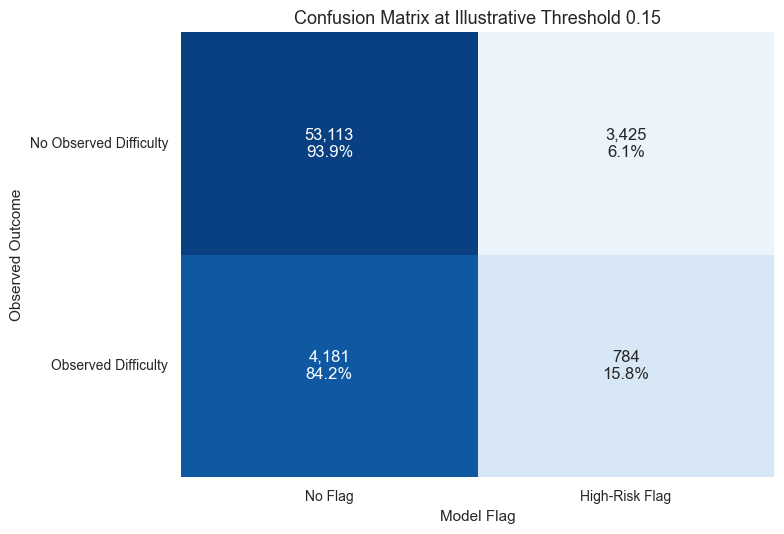

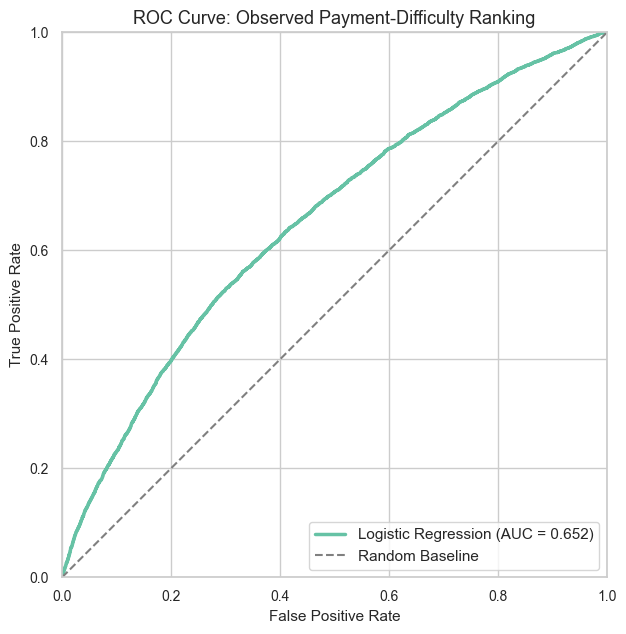

'outputs/figures/roc_curve.png'

In [18]:
# Confusion matrix at the illustrative 0.15 threshold
cm_row_totals = cm.sum(axis=1, keepdims=True)
cm_row_percent = np.divide(cm, cm_row_totals, where=cm_row_totals != 0)
cm_annotations = np.array([
    [f"{cm[row, col]:,}\n{cm_row_percent[row, col]:.1%}" for col in range(cm.shape[1])]
    for row in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    cm_row_percent,
    annot=cm_annotations,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    cbar=False,
    xticklabels=["No Flag", "High-Risk Flag"],
    yticklabels=["No Observed Difficulty", "Observed Difficulty"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix at Illustrative Threshold {CLASSIFICATION_THRESHOLD:.2f}")
ax.set_xlabel("Model Flag")
ax.set_ylabel("Observed Outcome")
ax.tick_params(axis="y", rotation=0)
save_figure(fig, "confusion_matrix_threshold_015.png")

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_holdout, y_pred_proba)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(fpr, tpr, linewidth=2.5, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random Baseline")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.set_title("ROC Curve: Observed Payment-Difficulty Ranking")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
save_figure(fig, "roc_curve.png")

## 13. Risk Segmentation

Holdout applications are segmented by their model-generated **Payment-Difficulty Score**:

- Low Risk: score < 0.05
- Medium Risk: 0.05 <= score < 0.15
- High Risk: score >= 0.15

The interval logic uses left-closed boundaries so scores equal to `0.05` enter Medium Risk and scores equal to `0.15` enter High Risk. Segment event rates, differences, and lift are compared with the **holdout** observed payment-difficulty rate, not the full-sample rate.

The model scores are generated from holdout features clipped with training-derived bounds. Segment-level income, credit, and credit-to-income averages are descriptive statistics calculated from the corresponding **unclipped holdout features**. The score is not presented as a calibrated probability.

The High Risk segment illustrates how the score can identify a smaller group with a higher observed event rate. It is a descriptive score range, not an automatic lending decision rule.

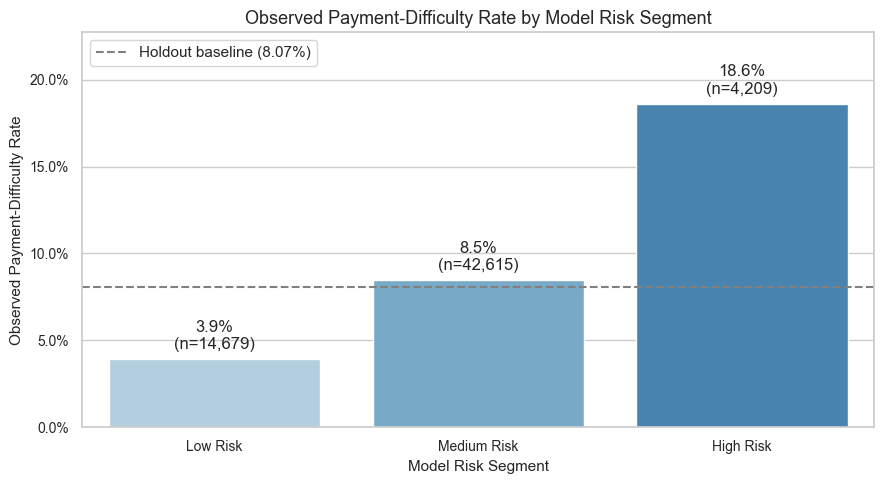

,risk_segment,application_count,observed_payment_difficulty_count,observed_payment_difficulty_rate,baseline_payment_difficulty_rate,payment_difficulty_rate_difference_vs_baseline,payment_difficulty_rate_lift_vs_baseline,avg_payment_difficulty_score,avg_income,avg_credit,avg_credit_income_ratio
0,Low Risk,14679,577,0.0393,0.0807,-0.0414,0.4869,0.0361,"197,164.7176","759,346.1039",4.2194
1,Medium Risk,42615,3604,0.0846,0.0807,0.0038,1.0476,0.0860,"160,926.8847","552,193.3540",3.8654
2,High Risk,4209,784,0.1863,0.0807,0.1055,2.3074,0.1789,"146,330.1497","495,822.9761",3.8715


,check,observed,expected
0,Risk segment application counts sum to holdout...,"61,503.0000","61,503.0000"
1,Risk segment observed event counts sum to hold...,"4,965.0000","4,965.0000"
2,High Risk application count equals threshold-0...,"4,209.0000","4,209.0000"
3,High Risk observed event rate equals threshold...,0.1863,0.1863
4,Confusion matrix cells sum to holdout rows,"61,503.0000","61,503.0000"


Saved risk segment summary to: outputs/risk_segment_summary.csv


In [19]:
risk_results = X_holdout_unclipped.copy()

assert risk_results.index.equals(X_holdout.index)
assert risk_results.index.equals(y_holdout.index)
assert risk_results.index.equals(payment_difficulty_scores.index)

risk_results["TARGET"] = y_holdout
risk_results["payment_difficulty_score"] = payment_difficulty_scores
risk_results["risk_segment"] = pd.cut(
    risk_results["payment_difficulty_score"],
    bins=[-np.inf, LOW_RISK_CUTOFF, HIGH_RISK_CUTOFF, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    right=False,
)

risk_segment_summary = (
    risk_results.groupby("risk_segment", observed=False)
    .agg(
        application_count=("TARGET", "size"),
        observed_payment_difficulty_count=("TARGET", "sum"),
        observed_payment_difficulty_rate=("TARGET", "mean"),
        avg_payment_difficulty_score=("payment_difficulty_score", "mean"),
        avg_income=("AMT_INCOME_TOTAL", "mean"),
        avg_credit=("AMT_CREDIT", "mean"),
        avg_credit_income_ratio=("CREDIT_INCOME_RATIO", "mean"),
    )
    .reset_index()
)
risk_segment_summary["observed_payment_difficulty_count"] = (
    risk_segment_summary["observed_payment_difficulty_count"].astype(int)
)
risk_segment_summary["baseline_payment_difficulty_rate"] = holdout_event_rate
risk_segment_summary["payment_difficulty_rate_difference_vs_baseline"] = (
    risk_segment_summary["observed_payment_difficulty_rate"]
    - risk_segment_summary["baseline_payment_difficulty_rate"]
)
risk_segment_summary["payment_difficulty_rate_lift_vs_baseline"] = (
    risk_segment_summary["observed_payment_difficulty_rate"]
    / risk_segment_summary["baseline_payment_difficulty_rate"]
)

risk_segment_summary = risk_segment_summary[
    [
        "risk_segment",
        "application_count",
        "observed_payment_difficulty_count",
        "observed_payment_difficulty_rate",
        "baseline_payment_difficulty_rate",
        "payment_difficulty_rate_difference_vs_baseline",
        "payment_difficulty_rate_lift_vs_baseline",
        "avg_payment_difficulty_score",
        "avg_income",
        "avg_credit",
        "avg_credit_income_ratio",
    ]
]

risk_summary_path = OUTPUT_DIR / "risk_segment_summary.csv"
risk_segment_summary.to_csv(risk_summary_path, index=False)

high_risk_row = risk_segment_summary.loc[
    risk_segment_summary["risk_segment"] == "High Risk"
].iloc[0]
threshold_015_row = threshold_comparison.loc[
    np.isclose(threshold_comparison["threshold"], CLASSIFICATION_THRESHOLD)
].iloc[0]

segment_application_count_check = int(risk_segment_summary["application_count"].sum())
segment_event_count_check = int(
    risk_segment_summary["observed_payment_difficulty_count"].sum()
)
high_risk_application_count_check = int(high_risk_row["application_count"])
confusion_total_check = int(cm.sum())

assert segment_application_count_check == len(X_holdout)
assert segment_event_count_check == int(y_holdout.sum())
assert high_risk_application_count_check == int(
    threshold_015_row["flagged_application_count"]
)
assert np.isclose(
    high_risk_row["observed_payment_difficulty_rate"],
    threshold_015_row["precision"],
)
assert confusion_total_check == len(X_holdout)

consistency_checks = pd.DataFrame([
    {
        "check": "Risk segment application counts sum to holdout rows",
        "observed": segment_application_count_check,
        "expected": len(X_holdout),
    },
    {
        "check": "Risk segment observed event counts sum to holdout positive cases",
        "observed": segment_event_count_check,
        "expected": int(y_holdout.sum()),
    },
    {
        "check": "High Risk application count equals threshold-0.15 flagged count",
        "observed": high_risk_application_count_check,
        "expected": int(threshold_015_row["flagged_application_count"]),
    },
    {
        "check": "High Risk observed event rate equals threshold-0.15 precision",
        "observed": high_risk_row["observed_payment_difficulty_rate"],
        "expected": threshold_015_row["precision"],
    },
    {
        "check": "Confusion matrix cells sum to holdout rows",
        "observed": confusion_total_check,
        "expected": len(X_holdout),
    },
])

risk_segment_order = ["Low Risk", "Medium Risk", "High Risk"]
risk_segment_plot = (
    risk_segment_summary
    .set_index("risk_segment")
    .loc[risk_segment_order]
    .reset_index()
)
holdout_baseline = risk_segment_plot["baseline_payment_difficulty_rate"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5))
segment_colors = sns.color_palette("Blues", n_colors=5)[1:4]
sns.barplot(
    data=risk_segment_plot,
    x="risk_segment",
    y="observed_payment_difficulty_rate",
    order=risk_segment_order,
    palette=segment_colors,
    hue="risk_segment",
    legend=False,
    ax=ax,
)
ax.axhline(
    holdout_baseline,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Holdout baseline ({holdout_baseline:.2%})",
)
ax.set_title("Observed Payment-Difficulty Rate by Model Risk Segment")
ax.set_xlabel("Model Risk Segment")
ax.set_ylabel("Observed Payment-Difficulty Rate")
ax.set_ylim(0, risk_segment_plot["observed_payment_difficulty_rate"].max() * 1.22)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
for patch, row in zip(ax.patches, risk_segment_plot.itertuples(index=False)):
    ax.annotate(
        f"{row.observed_payment_difficulty_rate:.1%}\n(n={row.application_count:,})",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
    )
ax.legend(loc="upper left")
save_figure(fig, "payment_difficulty_rate_by_risk_segment.png")

display(risk_segment_summary)
display(consistency_checks)
print(f"Saved risk segment summary to: {project_relative_path(risk_summary_path)}")

## 14. Business Insights

This model is a simple risk-ranking and segmentation baseline. Observed associations can help frame further questions, but they do not establish causality.

The main result is the trade-off between a small flagged group and low recall. Further work would need calibration, cost assumptions, a separate test design, and richer credit or repayment data.

In [20]:
high_risk_row = risk_segment_summary.loc[
    risk_segment_summary["risk_segment"] == "High Risk"
].iloc[0]
low_risk_row = risk_segment_summary.loc[
    risk_segment_summary["risk_segment"] == "Low Risk"
].iloc[0]

top_education = education_payment_difficulty_rate.iloc[0]
top_family_status = family_payment_difficulty_rate.iloc[0]

insights = [
    f"The full-sample observed payment-difficulty rate is {full_sample_event_rate:.1%}; the holdout rate is {holdout_event_rate:.1%}.",
    f"The holdout ROC-AUC is {roc_auc:.3f}, indicating modest ranking power from a limited, interpretable feature set.",
    f"The illustrative 0.15 threshold flags {high_risk_row['application_count']:,.0f} applications ({high_risk_row['application_count'] / len(X_holdout):.1%} of the holdout set).",
    f"The High Risk segment's observed payment-difficulty rate is {high_risk_row['observed_payment_difficulty_rate']:.1%}, {high_risk_row['payment_difficulty_rate_lift_vs_baseline']:.1f}x the holdout baseline and {high_risk_row['payment_difficulty_rate_difference_vs_baseline'] * 100:.1f} percentage points higher.",
    f"The Low Risk segment's observed payment-difficulty rate is {low_risk_row['observed_payment_difficulty_rate']:.1%}, below the holdout baseline.",
    f"The highest descriptive rate by education level is '{top_education['NAME_EDUCATION_TYPE']}' at {top_education['payment_difficulty_rate']:.1%}.",
    f"The highest descriptive rate by family status is '{top_family_status['NAME_FAMILY_STATUS']}' at {top_family_status['payment_difficulty_rate']:.1%}.",
    "Accuracy alone would be misleading under class imbalance; ROC-AUC measures ranking, precision measures review yield, and recall measures risk capture.",
    "The 0.15 threshold is illustrative rather than cost-optimized or independently validated, and its relatively low recall limits coverage.",
    "The segments summarize score ranges and are not lending decision rules.",
    "Main limitations are public application-only data, one holdout split, uncalibrated scores, and no cost-based threshold.",
]

for index, insight in enumerate(insights, start=1):
    print(f"{index}. {insight}")

1. The full-sample observed payment-difficulty rate is 8.1%; the holdout rate is 8.1%.
2. The holdout ROC-AUC is 0.652, indicating modest ranking power from a limited, interpretable feature set.
3. The illustrative 0.15 threshold flags 4,209 applications (6.8% of the holdout set).
4. The High Risk segment's observed payment-difficulty rate is 18.6%, 2.3x the holdout baseline and 10.6 percentage points higher.
5. The Low Risk segment's observed payment-difficulty rate is 3.9%, below the holdout baseline.
6. The highest descriptive rate by education level is 'Lower secondary' at 10.9%.
7. The highest descriptive rate by family status is 'Civil marriage' at 9.9%.
8. Accuracy alone would be misleading under class imbalance; ROC-AUC measures ranking, precision measures review yield, and recall measures risk capture.
9. The 0.15 threshold is illustrative rather than cost-optimized or independently validated, and its relatively low recall limits coverage.
10. The segments summarize score rang